In [1]:
# NETWORK TRAFFIC & SECURITY INSIGHTS DASHBOARD

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rf = pd.read_csv("logs.csv")
rf.columns = rf.columns.str.strip()
print(rf.columns)

print(rf.head())

Index(['timestamp', 'source_ip', 'dest_ip', 'protocol', 'action',
       'threat_label', 'log_type', 'bytes_transferred', 'user_agent',
       'request_path'],
      dtype='object')
             timestamp      source_ip        dest_ip protocol   action  \
0  2024-05-01T00:00:00  192.168.1.125  192.168.1.124      TCP  blocked   
1  2024-07-18T00:00:00  192.168.1.201  192.168.1.201     ICMP  blocked   
2  2024-04-07T00:00:00  192.168.1.248   192.168.1.15     HTTP  allowed   
3  2024-10-26T00:00:00  192.168.1.236  192.168.1.219     HTTP  allowed   
4  2024-10-31T00:00:00  192.168.1.221   192.168.1.61     ICMP  allowed   

  threat_label     log_type  bytes_transferred  \
0       benign     firewall              10889   
1       benign  application              36522   
2       benign  application              20652   
3       benign  application               5350   
4       benign  application              40691   

                                          user_agent request_path  
0   

In [3]:
print("\n DATASET INFORMATION")
print(rf.info())


 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 10 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   timestamp          object
 1   source_ip          object
 2   dest_ip            object
 3   protocol           object
 4   action             object
 5   threat_label       object
 6   log_type           object
 7   bytes_transferred  int64 
 8   user_agent         object
 9   request_path       object
dtypes: int64(1), object(9)
memory usage: 457.8+ MB
None


In [4]:
#remove duplicates and handle missing value
rf = rf.drop_duplicates()
rf = rf.dropna()

In [5]:
#Rows and column
print("\n Rows and Columns")
print(rf.shape)


 Rows and Columns
(6000000, 10)


In [6]:
#Function for Finding Suspicious IPS

def find_suspicious_ips(data):
    blocked = data[data["action"] == "blocked"]
    suspicious = blocked["source_ip"].value_counts()
    return suspicious

In [7]:
#Function to show protocl usage

def show_protocols(data):
    protocols = data["protocol"].value_counts()
    return protocols

In [8]:
# Threat level count

print("\nThreat Label Count")
print(rf["threat_label"].value_counts())


Threat Label Count
benign        5517611
suspicious     360883
malicious      121506
Name: threat_label, dtype: int64


In [9]:
#Blocked Requests

blocked_requests = rf[rf["action"] == "blocked"]
print("\nTotal Block Requests")
print(len(blocked_requests))


Total Block Requests
2999354


In [10]:
#Suspicious Ip Analysis

suspicious_ips = find_suspicious_ips(rf)
print("\nTop Suspicious source IPS")
print(suspicious_ips.head(10))


Top Suspicious source IPS
88.72.40.56       9222
25.169.111.91     9213
59.211.9.207      9195
44.137.187.63     9195
109.9.8.24        9158
55.139.34.186     9151
144.138.68.192    9143
193.69.197.165    9139
207.79.62.15      9137
187.14.173.168    9128
Name: source_ip, dtype: int64


In [11]:
rf.head(10)

,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01T00:00:00,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18T00:00:00,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07T00:00:00,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login
3,2024-10-26T00:00:00,192.168.1.236,192.168.1.219,HTTP,allowed,benign,application,5350,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,/login
4,2024-10-31T00:00:00,192.168.1.221,192.168.1.61,ICMP,allowed,benign,application,40691,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/
5,2024-12-02T00:00:00,192.168.1.134,192.168.1.81,FTP,allowed,benign,application,15742,curl/7.64.1,/backup
6,2024-03-08T00:00:00,192.168.1.77,192.168.1.118,UDP,allowed,benign,firewall,30134,SQLMap/1.6-dev,/
7,2024-02-07T00:00:00,192.168.1.130,192.168.1.68,TCP,blocked,benign,firewall,16109,curl/7.64.1,/
8,2024-03-21T00:00:00,192.168.1.140,192.168.1.181,UDP,allowed,benign,application,36446,curl/7.64.1,/
9,2024-03-09T00:00:00,192.168.1.228,192.168.1.28,HTTPS,allowed,benign,ids,18565,SQLMap/1.6-dev,/secure


In [12]:
#Protocol Usage

print("\nProtocol Usage")
print(show_protocols(rf))


Protocol Usage
TCP      1497493
HTTP     1201528
HTTPS    1199970
UDP       900422
ICMP      599903
SSH       300464
FTP       300220
Name: protocol, dtype: int64


In [13]:
#Top request paths

print("\nTop Request Paths")
print(rf["request_path"].value_counts().head())



Top Request Paths
/                2741075
/login            414760
/admin/config     226796
/secure           226412
/auth             225761
Name: request_path, dtype: int64


In [14]:
#Most Targeted Destination Ips

print("\nTop Destination Ips")
print(rf["dest_ip"].value_counts().head())


Top Destination Ips
192.168.1.5      24140
192.168.1.135    24121
192.168.1.193    24091
192.168.1.226    24042
192.168.1.237    23972
Name: dest_ip, dtype: int64


In [15]:
#Total Bytes Transfered
print("\nTotal Bytes Transferred")
print(rf["bytes_transferred"].value_counts().head())


Total Bytes Transferred
22906    170
26654    166
25391    166
40000    163
25367    162
Name: bytes_transferred, dtype: int64


In [16]:
total_requests = len(rf)

blocked_requests = len(
    rf[rf["action"] == "blocked"]
)

allowed_requests = len(
    rf[rf["action"] == "allowed"]
)

malicious_requests = len(
    rf[rf["threat_label"] == "malicious"]
)

suspicious_requests = len(
    rf[rf["threat_label"] == "suspicious"]
)

benign_requests = len(
    rf[rf["threat_label"] == "benign"]
)

print("\n=========================")
print("SECURITY KPI METRICS")
print("=========================")

print("Total Requests :", total_requests)
print("Blocked Requests :", blocked_requests)
print("Allowed Requests :", allowed_requests)
print("Malicious Requests :", malicious_requests)
print("Suspicious Requests :", suspicious_requests)
print("Benign Requests :", benign_requests)



SECURITY KPI METRICS
Total Requests : 6000000
Blocked Requests : 2999354
Allowed Requests : 3000646
Malicious Requests : 121506
Suspicious Requests : 360883
Benign Requests : 5517611


In [17]:
# SECURITY RISK SCORE

malicious_percent = (
    malicious_requests / total_requests
) * 100

if malicious_percent < 5:

    risk_level = "LOW RISK"

elif malicious_percent < 15:

    risk_level = "MEDIUM RISK"

else:

    risk_level = "HIGH RISK"

print("\nSECURITY RISK LEVEL")
print(risk_level)


SECURITY RISK LEVEL
LOW RISK


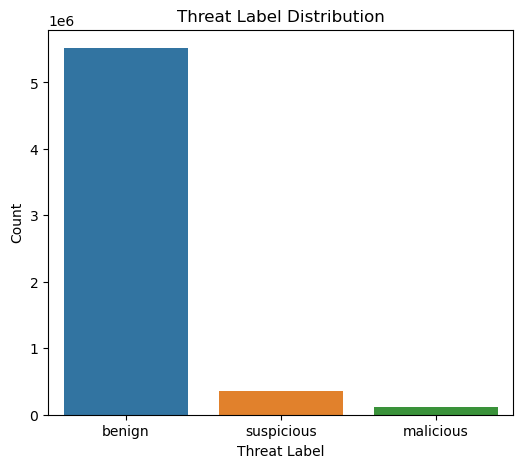

In [18]:
# VISUALIZATION 1
# THREAT LABEL DISTRIBUTION

plt.figure(figsize=(6,5))
sns.countplot(
    x="threat_label",
    data=rf
)

plt.title("Threat Label Distribution")

plt.xlabel("Threat Label")

plt.ylabel("Count")

plt.show()


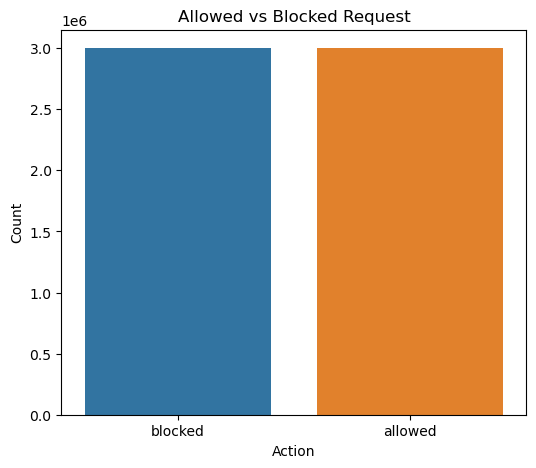

In [19]:
# VISUALIZATION 2
# ALLOWED VS BLOCKED REQUESTS

plt.figure(figsize=(6,5))

sns.countplot(
    x = "action",
    data = rf
)

plt.title("Allowed vs Blocked Request")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()

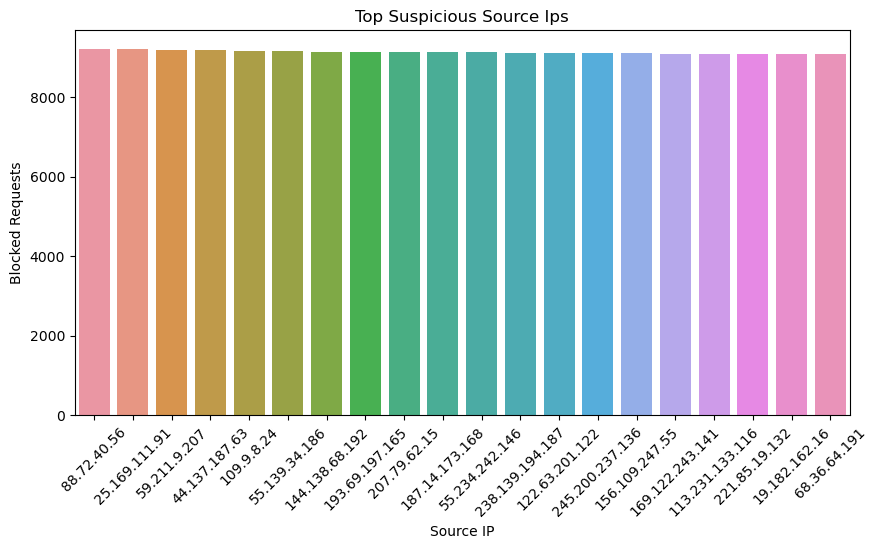

In [20]:
# VISUALIZATION 3
# TOP SUSPICIOUS IPS

top_ips = suspicious_ips.head(20)

plt.figure(figsize = (10,5))

sns.barplot(
    x = top_ips.index,
    y = top_ips.values
)

plt.title("Top Suspicious Source Ips")
plt.xlabel("Source IP")
plt.ylabel("Blocked Requests")
plt.xticks(rotation=45)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

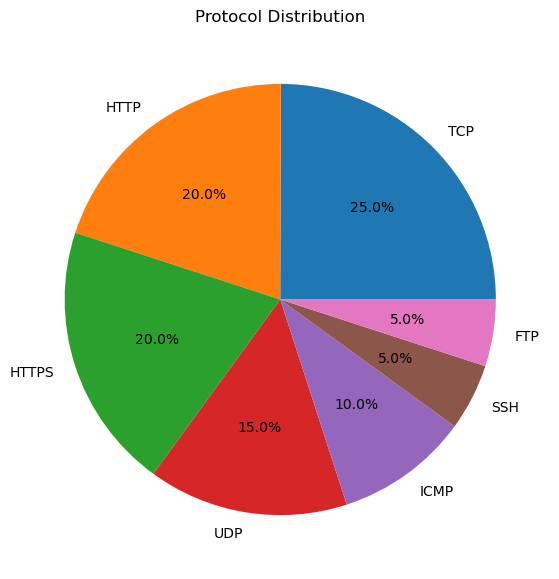

In [21]:
# VISUALIZATION 4
# PROTOCOL DISTRIBUTION

protocol_count = rf["protocol"].value_counts()

plt.figure(figsize=(7,7))

protocol_count.plot(
    kind = "pie",
    autopct = "%1.1f%%"
)

plt.title("Protocol Distribution")
plt.ylabel("")
plt.show

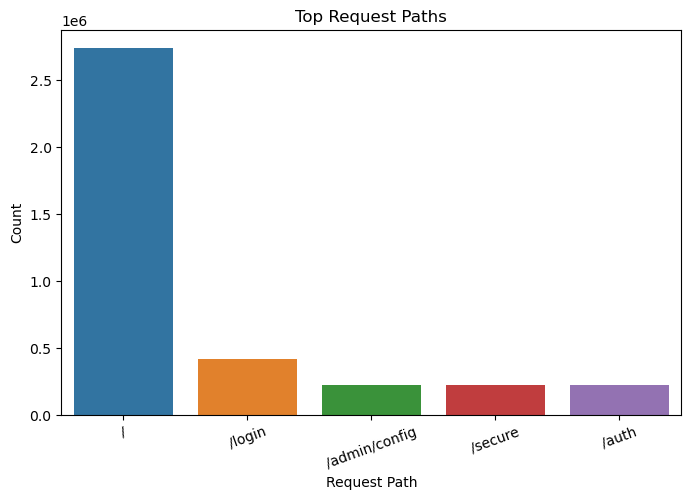

In [22]:
# VISUALIZATION 5
# TOP REQUEST PATHS

top_paths = rf["request_path"].value_counts().head(5)

plt.figure(figsize=(8,5))

sns.barplot(
    x = top_paths.index,
    y = top_paths.values
)

plt.title("Top Request Paths")
plt.xlabel("Request Path")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

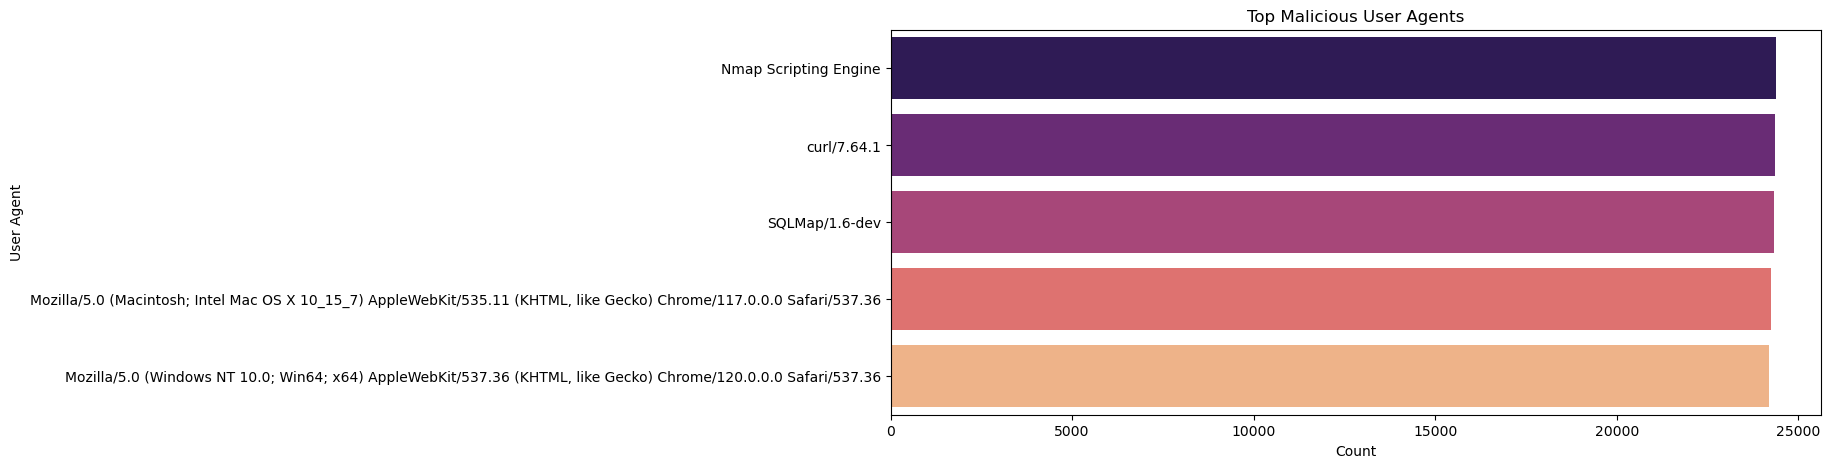

In [23]:
# VISUALIZATION 6
# TOP MALICIOUS USER AGENTS

malicious_agents = rf[
    rf["threat_label"] == "malicious"
]

top_agents = malicious_agents[
    "user_agent"
].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_agents.values,
    y=top_agents.index,
    palette="magma"
)

plt.title("Top Malicious User Agents")
plt.xlabel("Count")
plt.ylabel("User Agent")

plt.show()



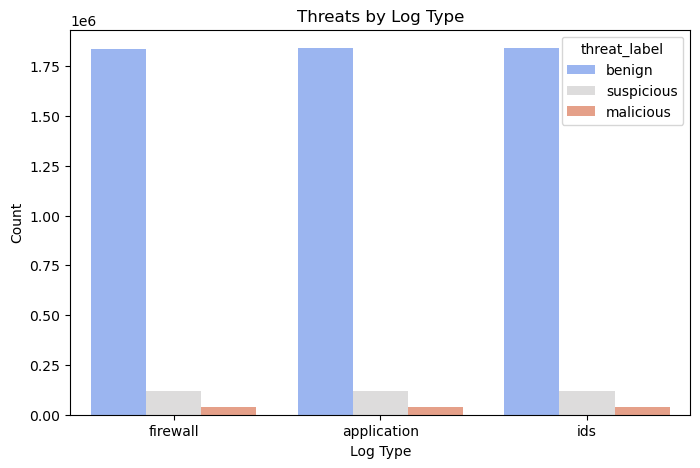

In [27]:
#Visualization 7
#Log Type Analysis

plt.figure(figsize=(8,5))

sns.countplot(
    x="log_type",
    data=rf,
    hue="threat_label",
    palette="coolwarm"
)

plt.title("Threats by Log Type")
plt.xlabel("Log Type")
plt.ylabel("Count")

plt.show()


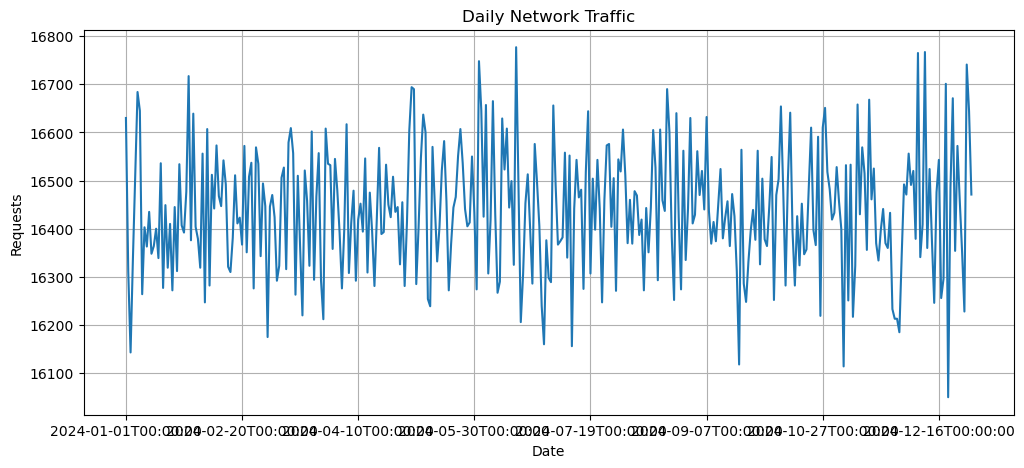

In [29]:
#Visualization 8
#Daily Network Traffic

daily_traffic = rf.groupby("timestamp")["action"].count()

plt.figure(figsize=(12,5))

daily_traffic.plot()

plt.title("Daily Network Traffic")
plt.xlabel("Date")
plt.ylabel("Requests")

plt.grid(True)

plt.show()

In [26]:
# EXPORT REPORT

suspicious_ips.to_csv(
    "suspicious_ips_report.csv"
)

print("\nSUSPICIOUS IP REPORT SAVED SUCCESSFULLY")


# NETWORKING CONCEPTS USED

print("\nNETWORKING CONCEPTS USED IN PROJECT")

print("""

1. IP Address:
   Identifies devices in the network.

2. Protocol:
   Rules used for communication such as HTTP,
   TCP, HTTPS, FTP.

3. Blocked Requests:
   Requests denied due to suspicious behavior.

4. Traffic Analysis:
   Monitoring movement of network data.

5. Threat Detection:
   Detecting malicious or suspicious activity.

6. Firewall Logs:
   Security records generated by firewalls.

7. Intrusion Detection:
   Identifying possible cyber attacks.

8. User Agent Analysis:
   Detecting suspicious browser or tool activity.

9. Security Risk Analysis:
   Measuring overall network threat level.

""")

print("\nPROJECT COMPLETED SUCCESSFULLY")


SUSPICIOUS IP REPORT SAVED SUCCESSFULLY

NETWORKING CONCEPTS USED IN PROJECT


1. IP Address:
   Identifies devices in the network.

2. Protocol:
   Rules used for communication such as HTTP,
   TCP, HTTPS, FTP.

3. Blocked Requests:
   Requests denied due to suspicious behavior.

4. Traffic Analysis:
   Monitoring movement of network data.

5. Threat Detection:
   Detecting malicious or suspicious activity.

6. Firewall Logs:
   Security records generated by firewalls.

7. Intrusion Detection:
   Identifying possible cyber attacks.

8. User Agent Analysis:
   Detecting suspicious browser or tool activity.

9. Security Risk Analysis:
   Measuring overall network threat level.



PROJECT COMPLETED SUCCESSFULLY
